## 1. Setup and Imports

In [1]:
import os
import sys
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, Polygon, LineString, box
from shapely.ops import nearest_points
import networkx as nx
import rasterio
from rasterio.mask import mask
from tqdm.auto import tqdm

# Add topolity modules to path
sys.path.append('/home/fbellisardi/code/topolity')
from data_processing import DEMReader

# Plotting configuration
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("✓ Imports successful")

✓ Imports successful


## 2. Configuration

In [2]:
# City selection
CITY = "barcelone"  # Options: santiago, barcelone, madrid, rome, boston

# City to country code mapping for WorldPop
CITY_TO_COUNTRY = {
    "santiago": "chl",    # Chile
    "barcelone": "esp",   # Spain (España)
    "barcelona": "esp",   # Spain
    "madrid": "esp",      # Spain
    "rome": "ita",        # Italy (Italia)
    "boston": "usa"       # United States
}

# Paths
BASE_DIR = Path(f"/home/fbellisardi/code/topolity/data/data_processed/{CITY}")
GRAPH_FILE = BASE_DIR / "graphs_fine_grid" / "graph_original.pkl"
DEM_FILE = BASE_DIR / "dem" / f"{CITY}_dem.tif"
OUTPUT_DIR = Path(f"/home/fbellisardi/code/topolity/output/expansion_{CITY}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# WorldPop data (local files)
WORLDPOP_DIR = Path("/home/fbellisardi/code/topolity/data/worldpop/raw")
country_code = CITY_TO_COUNTRY.get(CITY.lower(), "chl")
WORLDPOP_FILE = WORLDPOP_DIR / f"{country_code}_ppp_2020_constrained.tif"

# Parameters
GRID_SIZE = 1000  # meters (1km × 1km cells)
BUFFER_DISTANCE = 2000  # meters from city edge to consider
DS = 10.0  # Sampling interval along edges (meters)
M = 1.0  # Mass (kg)
GRAV = 9.81  # Gravity (m/s²)

# Gravity model parameters
ALPHA = 1.0  # Population attraction exponent
BETA = 2.0   # Distance decay exponent
K = 1.0      # Scaling constant

print(f"City: {CITY}")
print(f"Graph: {GRAPH_FILE.exists()}")
print(f"DEM: {DEM_FILE.exists()}")
print(f"WorldPop: {WORLDPOP_FILE.exists()}")
print(f"Output: {OUTPUT_DIR}")

City: barcelone
Graph: True
DEM: True
WorldPop: True
Output: /home/fbellisardi/code/topolity/output/expansion_barcelone


## 3. Load Original Network

In [3]:
# Load graph
print(f"Loading graph from {GRAPH_FILE}...")
with open(GRAPH_FILE, 'rb') as f:
    G_original = pickle.load(f)

print(f"✓ Graph loaded: {G_original.number_of_nodes()} nodes, {G_original.number_of_edges()} edges")

# Extract network extent
node_coords = np.array([[G_original.nodes[n]['x'], G_original.nodes[n]['y']] for n in G_original.nodes()])
x_coords, y_coords = node_coords[:, 0], node_coords[:, 1]

network_bounds = {
    'minx': x_coords.min(),
    'maxx': x_coords.max(),
    'miny': y_coords.min(),
    'maxy': y_coords.max()
}

print(f"Network bounds: {network_bounds}")

# Create GeoDataFrame of network nodes
nodes_gdf = gpd.GeoDataFrame(
    [{'node': n, 'geometry': Point(G_original.nodes[n]['x'], G_original.nodes[n]['y'])} 
     for n in G_original.nodes()],
    crs="EPSG:32719" if CITY == "santiago" else "EPSG:32631"  # UTM zones
)

print(f"✓ Network GeoDataFrame created: {len(nodes_gdf)} points")

Loading graph from /home/fbellisardi/code/topolity/data/data_processed/barcelone/graphs_fine_grid/graph_original.pkl...
✓ Graph loaded: 18329 nodes, 51509 edges
Network bounds: {'minx': np.float64(1.9409132), 'maxx': np.float64(2.4872722999999994), 'miny': np.float64(41.26427859999999), 'maxy': np.float64(41.6067913)}
✓ Network GeoDataFrame created: 18329 points


## 4. Generate Candidate Expansion Grid

Create a 1km × 1km grid around the network periphery to identify potential expansion areas.

In [4]:
# Create expanded bounding box
expansion_bounds = {
    'minx': network_bounds['minx'] - BUFFER_DISTANCE,
    'maxx': network_bounds['maxx'] + BUFFER_DISTANCE,
    'miny': network_bounds['miny'] - BUFFER_DISTANCE,
    'maxy': network_bounds['maxy'] + BUFFER_DISTANCE
}

# Generate grid
x_coords_grid = np.arange(expansion_bounds['minx'], expansion_bounds['maxx'], GRID_SIZE)
y_coords_grid = np.arange(expansion_bounds['miny'], expansion_bounds['maxy'], GRID_SIZE)

grid_cells = []
for i, x in enumerate(x_coords_grid):
    for j, y in enumerate(y_coords_grid):
        cell = box(x, y, x + GRID_SIZE, y + GRID_SIZE)
        grid_cells.append({
            'cell_id': f"{i}_{j}",
            'centroid_x': x + GRID_SIZE/2,
            'centroid_y': y + GRID_SIZE/2,
            'geometry': cell
        })

grid_gdf = gpd.GeoDataFrame(grid_cells, crs=nodes_gdf.crs)

print(f"✓ Generated {len(grid_gdf)} candidate expansion cells")

# Filter to peripheral cells only (outside current network but within buffer)
network_hull = nodes_gdf.unary_union.convex_hull.buffer(500)  # 500m buffer around network
grid_gdf['is_peripheral'] = ~grid_gdf.geometry.within(network_hull)
peripheral_cells = grid_gdf[grid_gdf['is_peripheral']].copy()

print(f"✓ Filtered to {len(peripheral_cells)} peripheral cells for expansion analysis")

✓ Generated 25 candidate expansion cells
✓ Filtered to 25 peripheral cells for expansion analysis


## 5. Extract Population Data (WorldPop)

Download WorldPop data if not available, then extract population for each candidate cell.

In [5]:
# Check if WorldPop file exists
if not WORLDPOP_FILE.exists():
    print(f"⚠ WorldPop data not found at {WORLDPOP_FILE}")
    print(f"Please download from: https://hub.worldpop.org/geodata/listing?id=29")
    print(f"For {CITY}, download the constrained population raster and place it at:")
    print(f"  {WORLDPOP_FILE}")
    
    # Create dummy population data for testing
    print("\nGenerating synthetic population data for demonstration...")
    np.random.seed(42)
    peripheral_cells['population'] = np.random.lognormal(6, 1.5, len(peripheral_cells)).astype(int)
    peripheral_cells['population'] = peripheral_cells['population'].clip(100, 10000)
else:
    print(f"Loading WorldPop data from {WORLDPOP_FILE}...")
    
    # Extract population for each cell
    populations = []
    with rasterio.open(WORLDPOP_FILE) as src:
        for idx, row in tqdm(peripheral_cells.iterrows(), total=len(peripheral_cells), desc="Extracting population"):
            try:
                # Mask raster with cell geometry
                out_image, out_transform = mask(src, [row.geometry], crop=True, nodata=0)
                population = out_image.sum()
                populations.append(max(0, population))
            except Exception as e:
                populations.append(0)
    
    peripheral_cells['population'] = populations

# Filter cells with significant population
peripheral_cells = peripheral_cells[peripheral_cells['population'] > 50].copy()

print(f"✓ Population extracted: {len(peripheral_cells)} cells with population > 50")
print(f"  Total population in peripheral cells: {peripheral_cells['population'].sum():,.0f}")
print(f"  Mean population per cell: {peripheral_cells['population'].mean():,.0f}")
print(f"  Median population per cell: {peripheral_cells['population'].median():,.0f}")

Loading WorldPop data from /home/fbellisardi/code/topolity/data/worldpop/raw/esp_ppp_2020_constrained.tif...


Extracting population: 100%|██████████| 25/25 [00:22<00:00,  1.11it/s]

✓ Population extracted: 4 cells with population > 50
  Total population in peripheral cells: 53,190,415
  Mean population per cell: 13,297,604
  Median population per cell: 9,443,444


## 6. Load Digital Elevation Model

In [6]:
# Load DEM
print(f"Loading DEM from {DEM_FILE}...")
dem_src = rasterio.open(str(DEM_FILE))

# Sample elevation at cell centroids
centroid_coords = [(row.centroid_x, row.centroid_y) for _, row in peripheral_cells.iterrows()]
elevations = [val[0] for val in dem_src.sample(centroid_coords)]
peripheral_cells['elevation'] = elevations

print(f"✓ DEM loaded and elevations sampled")
print(f"  Elevation range: {peripheral_cells['elevation'].min():.1f} - {peripheral_cells['elevation'].max():.1f} m")
print(f"  Mean elevation: {peripheral_cells['elevation'].mean():.1f} m")

Loading DEM from /home/fbellisardi/code/topolity/data/data_processed/barcelone/dem/barcelone_dem.tif...
✓ DEM loaded and elevations sampled
  Elevation range: 0.0 - 0.0 m
  Mean elevation: 0.0 m


## 7. Compute Network Distances and Connectivity

For each expansion cell, find the nearest network node and compute the connection distance.

In [7]:
# Find nearest network node for each expansion cell
print("Computing nearest network nodes...")

nearest_nodes = []
connection_distances = []
elevation_differences = []

for idx, cell_row in tqdm(peripheral_cells.iterrows(), total=len(peripheral_cells), desc="Finding connections"):
    cell_point = Point(cell_row.centroid_x, cell_row.centroid_y)
    
    # Find nearest node
    distances = nodes_gdf.geometry.distance(cell_point)
    nearest_idx = distances.idxmin()
    nearest_node = nodes_gdf.loc[nearest_idx, 'node']
    min_distance = distances.min()
    
    # Get elevation of nearest node
    node_coords = (G_original.nodes[nearest_node]['x'], G_original.nodes[nearest_node]['y'])
    node_elev = dem_src.sample([node_coords]).__next__()[0]
    elev_diff = cell_row.elevation - node_elev
    
    nearest_nodes.append(nearest_node)
    connection_distances.append(min_distance)
    elevation_differences.append(elev_diff)

peripheral_cells['nearest_node'] = nearest_nodes
peripheral_cells['connection_distance'] = connection_distances
peripheral_cells['elevation_diff'] = elevation_differences

print(f"✓ Network connectivity computed")
print(f"  Mean connection distance: {peripheral_cells['connection_distance'].mean():.0f} m")
print(f"  Mean elevation difference: {peripheral_cells['elevation_diff'].mean():.1f} m")

Computing nearest network nodes...


Finding connections: 100%|██████████| 4/4 [00:00<00:00, 52.72it/s]

✓ Network connectivity computed
  Mean connection distance: 707 m
  Mean elevation difference: -173.8 m


## 8. Gravity Model: Estimate Mobility Demand

Apply a gravity model to estimate the potential OD flows between the existing network and expansion cells.

$$F_{ij} = K \frac{P_i^\alpha P_j^\alpha}{d_{ij}^\beta}$$

where $P_i$ and $P_j$ are populations, $d_{ij}$ is distance, and $\alpha, \beta, K$ are model parameters.

In [8]:
# Simplified gravity model: estimate trips from network to expansion cell
# Assume network population is concentrated at major nodes (heuristic)

print("Computing gravity model flows...")

# For simplicity, assume uniform population distribution across network
# In practice, you would use actual population data or activity centers
NETWORK_TOTAL_POP = peripheral_cells['population'].sum() * 5  # Assume network has 5× peripheral population

gravity_flows = []
for idx, cell_row in peripheral_cells.iterrows():
    P_dest = cell_row.population
    d_ij = cell_row.connection_distance
    
    # Gravity model flow
    if d_ij > 0:
        flow = K * (NETWORK_TOTAL_POP ** ALPHA) * (P_dest ** ALPHA) / (d_ij ** BETA)
    else:
        flow = 0
    
    gravity_flows.append(flow)

peripheral_cells['estimated_flow'] = gravity_flows

# Normalize flows to realistic trip counts (e.g., daily trips)
flow_sum = peripheral_cells['estimated_flow'].sum()
if flow_sum > 0:
    peripheral_cells['daily_trips'] = (peripheral_cells['estimated_flow'] / flow_sum * 10000).astype(int)
else:
    peripheral_cells['daily_trips'] = 0

print(f"✓ Gravity model flows computed")
print(f"  Total estimated daily trips: {peripheral_cells['daily_trips'].sum():,}")
print(f"  Mean trips per cell: {peripheral_cells['daily_trips'].mean():.0f}")

Computing gravity model flows...
✓ Gravity model flows computed
  Total estimated daily trips: 9,997
  Mean trips per cell: 2499


## 9. Compute Gravitational Work for Expansion Scenarios

Calculate the uphill gravitational work required to connect each expansion cell to the network.

In [9]:
print("Computing gravitational work for expansion scenarios...")

gravitational_works = []

for idx, cell_row in tqdm(peripheral_cells.iterrows(), total=len(peripheral_cells), desc="Computing work"):
    # Connection work: uphill component only
    elev_diff = cell_row.elevation_diff
    connection_dist = cell_row.connection_distance
    daily_trips = cell_row.daily_trips
    
    # Uphill work = m * g * Δh (if Δh > 0)
    if elev_diff > 0:
        work_per_trip = M * GRAV * elev_diff
    else:
        work_per_trip = 0
    
    # Total work considering all daily trips
    total_work = work_per_trip * daily_trips
    
    gravitational_works.append(total_work)

peripheral_cells['gravitational_work'] = gravitational_works

# Compute work per capita (normalized by population)
peripheral_cells['work_per_capita'] = (
    peripheral_cells['gravitational_work'] / peripheral_cells['population'].clip(lower=1)
)

print(f"✓ Gravitational work computed")
print(f"  Total work across all cells: {peripheral_cells['gravitational_work'].sum():,.0f} J")
print(f"  Mean work per cell: {peripheral_cells['gravitational_work'].mean():,.0f} J")
print(f"  Mean work per capita: {peripheral_cells['work_per_capita'].mean():.1f} J/person")

Computing gravitational work for expansion scenarios...


Computing work: 100%|██████████| 4/4 [00:00<00:00, 5616.74it/s]

✓ Gravitational work computed
  Total work across all cells: 0 J
  Mean work per cell: 0 J
  Mean work per capita: 0.0 J/person


## 10. Rank and Identify Optimal Expansion Zones

In [10]:
# Compute composite suitability score
# Lower work per capita = better (negative correlation)
# Higher population = better (positive correlation)
# Shorter connection distance = better (negative correlation)

# Normalize metrics to [0, 1]
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Invert work (lower is better)
peripheral_cells['work_score'] = 1 - scaler.fit_transform(
    peripheral_cells[['work_per_capita']]
)

# Population score (higher is better)
peripheral_cells['pop_score'] = scaler.fit_transform(
    peripheral_cells[['population']]
)

# Distance score (shorter is better)
peripheral_cells['dist_score'] = 1 - scaler.fit_transform(
    peripheral_cells[['connection_distance']]
)

# Composite suitability (weighted average)
W_WORK = 0.5  # Weight for energetic efficiency
W_POP = 0.3   # Weight for population
W_DIST = 0.2  # Weight for proximity

peripheral_cells['suitability_score'] = (
    W_WORK * peripheral_cells['work_score'] +
    W_POP * peripheral_cells['pop_score'] +
    W_DIST * peripheral_cells['dist_score']
)

# Rank cells
peripheral_cells = peripheral_cells.sort_values('suitability_score', ascending=False)

# Select top candidates
TOP_N = 20
top_expansion_zones = peripheral_cells.head(TOP_N)

print(f"\n{'='*60}")
print(f"TOP {TOP_N} EXPANSION ZONES (by suitability)")
print(f"{'='*60}\n")

for rank, (idx, row) in enumerate(top_expansion_zones.iterrows(), 1):
    print(f"{rank:2d}. Cell {row.cell_id}:")
    print(f"    Suitability: {row.suitability_score:.3f}")
    print(f"    Population: {row.population:,.0f}")
    print(f"    Elevation: {row.elevation:.1f} m (Δ={row.elevation_diff:+.1f} m)")
    print(f"    Connection distance: {row.connection_distance:.0f} m")
    print(f"    Work per capita: {row.work_per_capita:.1f} J/person")
    print()


TOP 20 EXPANSION ZONES (by suitability)

 1. Cell 1_1:
    Suitability: 0.800
    Population: 33,086,060
    Elevation: 0.0 m (Δ=-5.0 m)
    Connection distance: 707 m
    Work per capita: 0.0 J/person

 2. Cell 2_2:
    Suitability: 0.749
    Population: 6,411,004
    Elevation: 0.0 m (Δ=-237.0 m)
    Connection distance: 706 m
    Work per capita: 0.0 J/person

 3. Cell 1_2:
    Suitability: 0.679
    Population: 12,475,883
    Elevation: 0.0 m (Δ=-444.0 m)
    Connection distance: 707 m
    Work per capita: 0.0 J/person

 4. Cell 2_1:
    Suitability: 0.560
    Population: 1,217,468
    Elevation: 0.0 m (Δ=-9.0 m)
    Connection distance: 707 m
    Work per capita: 0.0 J/person



## 11. Visualization


✓ Visualization saved to /home/fbellisardi/code/topolity/output/expansion_barcelone


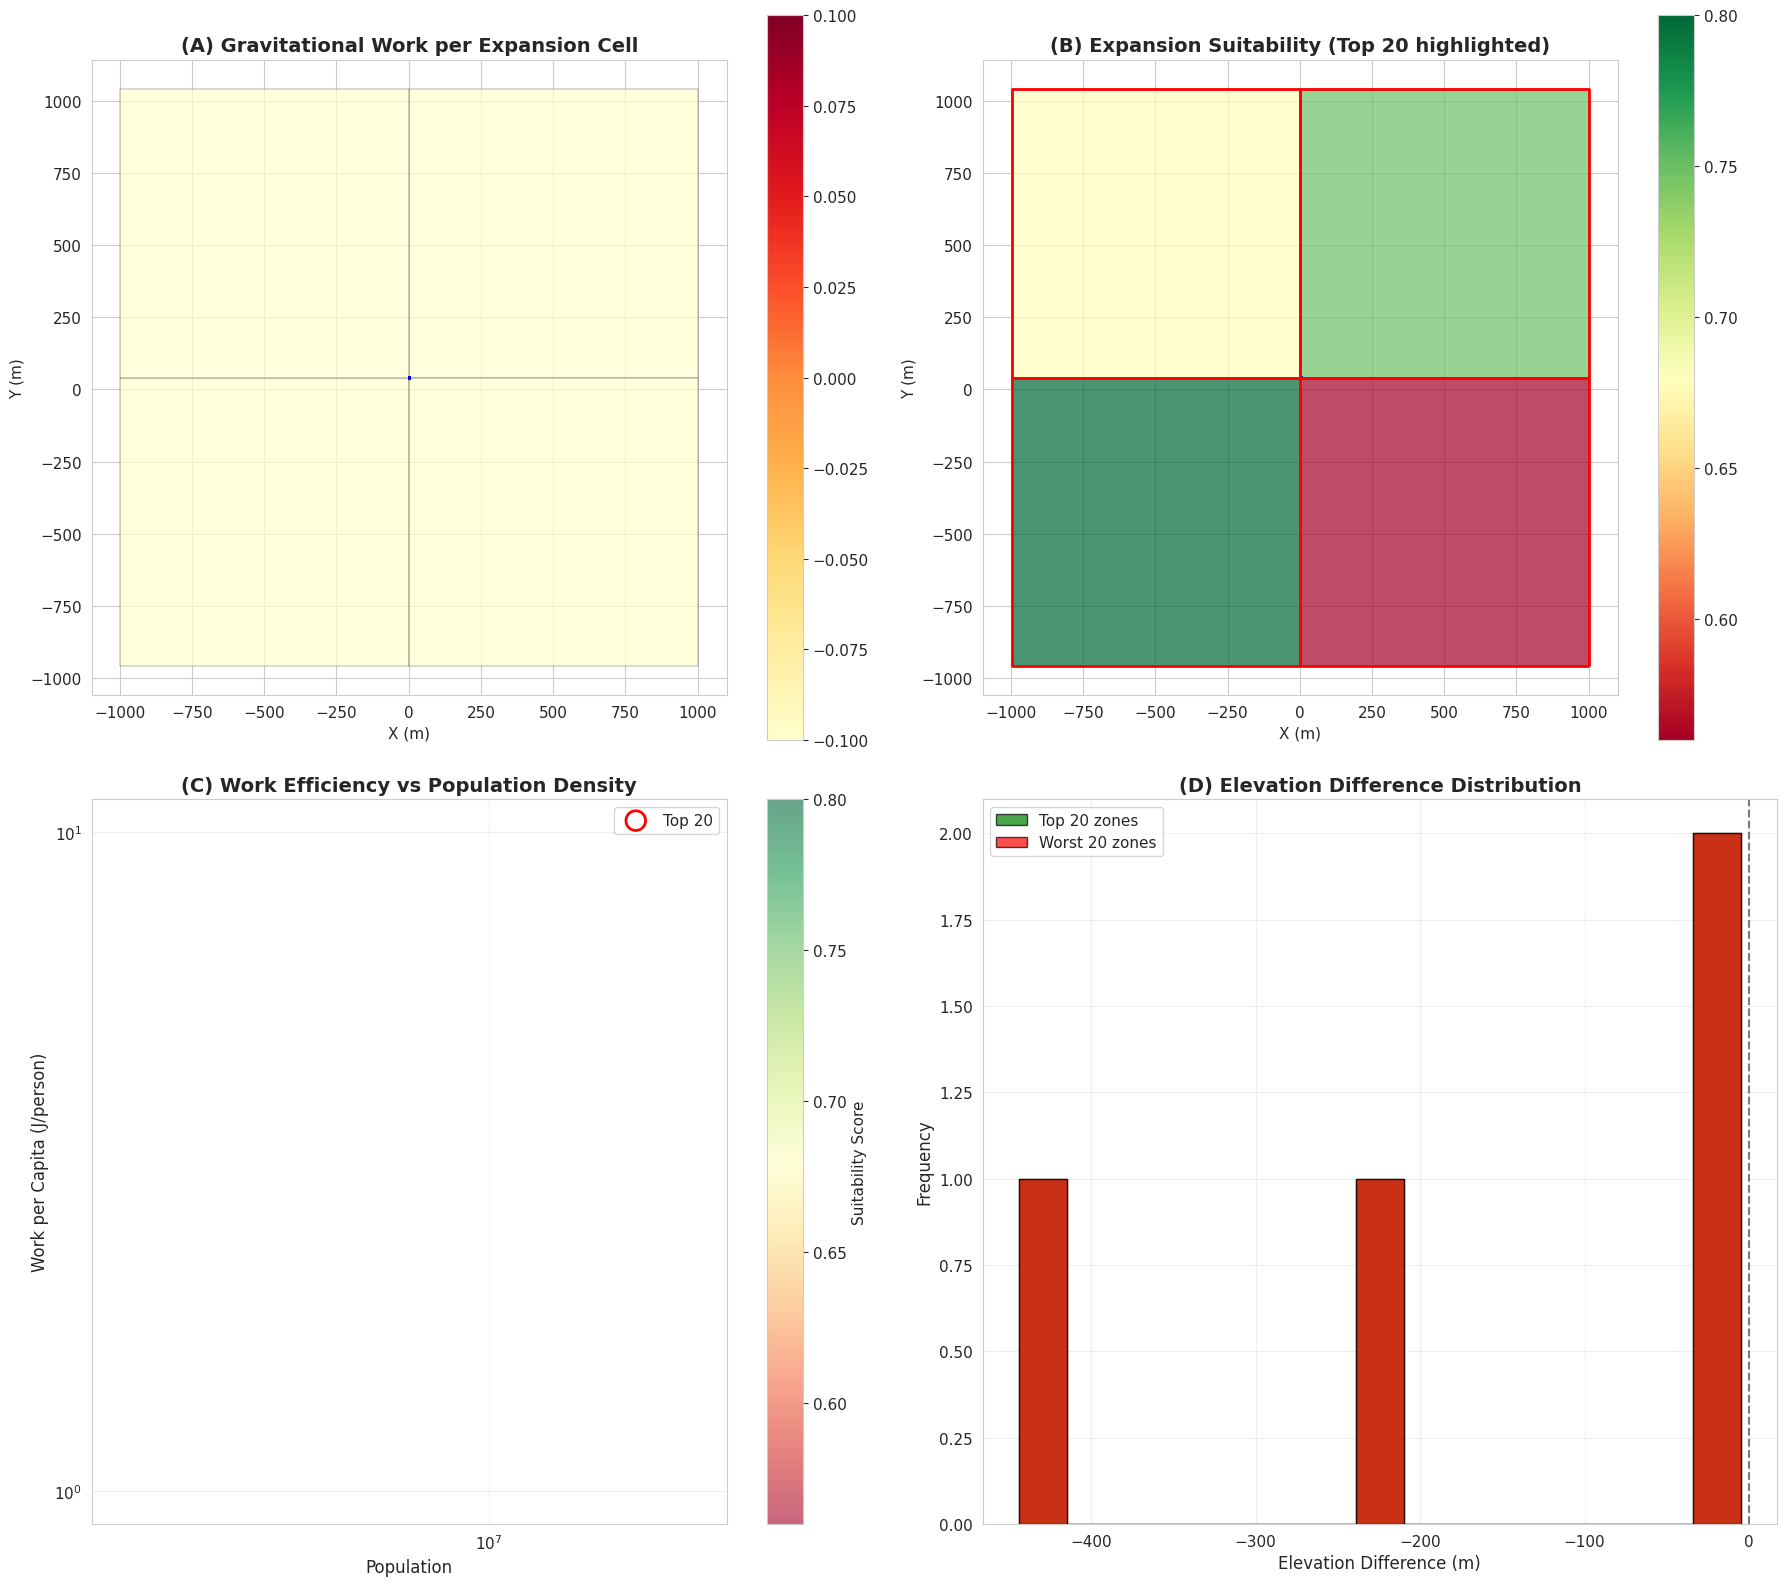

In [11]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Panel A: Gravitational work map
ax = axes[0, 0]
peripheral_cells.plot(
    column='gravitational_work',
    cmap='YlOrRd',
    legend=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.3,
    alpha=0.7
)
nodes_gdf.plot(ax=ax, color='blue', markersize=1, alpha=0.3)
ax.set_title('(A) Gravitational Work per Expansion Cell', fontsize=14, fontweight='bold')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

# Panel B: Suitability score map
ax = axes[0, 1]
peripheral_cells.plot(
    column='suitability_score',
    cmap='RdYlGn',
    legend=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.3,
    alpha=0.7
)
nodes_gdf.plot(ax=ax, color='blue', markersize=1, alpha=0.3)
top_expansion_zones.plot(ax=ax, color='none', edgecolor='red', linewidth=2)
ax.set_title(f'(B) Expansion Suitability (Top {TOP_N} highlighted)', fontsize=14, fontweight='bold')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

# Panel C: Work vs Population scatter
ax = axes[1, 0]
scatter = ax.scatter(
    peripheral_cells['population'],
    peripheral_cells['work_per_capita'],
    c=peripheral_cells['suitability_score'],
    cmap='RdYlGn',
    s=50,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
ax.scatter(
    top_expansion_zones['population'],
    top_expansion_zones['work_per_capita'],
    s=200,
    facecolors='none',
    edgecolors='red',
    linewidth=2,
    label=f'Top {TOP_N}'
)
plt.colorbar(scatter, ax=ax, label='Suitability Score')
ax.set_xlabel('Population', fontsize=12)
ax.set_ylabel('Work per Capita (J/person)', fontsize=12)
ax.set_title('(C) Work Efficiency vs Population Density', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Panel D: Elevation profile comparison
ax = axes[1, 1]

# Compare top zones vs worst zones
worst_zones = peripheral_cells.tail(TOP_N)

ax.hist(top_expansion_zones['elevation_diff'], bins=15, alpha=0.7, 
        label=f'Top {TOP_N} zones', color='green', edgecolor='black')
ax.hist(worst_zones['elevation_diff'], bins=15, alpha=0.7,
        label=f'Worst {TOP_N} zones', color='red', edgecolor='black')

ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Elevation Difference (m)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('(D) Elevation Difference Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{CITY}_expansion_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / f'{CITY}_expansion_analysis.pdf', dpi=300, bbox_inches='tight')
print(f"\n✓ Visualization saved to {OUTPUT_DIR}")
plt.show()

## 12. Export Results

In [12]:
# Save complete results
output_file = OUTPUT_DIR / f'{CITY}_expansion_candidates.gpkg'
peripheral_cells.to_file(output_file, driver='GPKG', layer='all_cells')
top_expansion_zones.to_file(output_file, driver='GPKG', layer='top_zones')

print(f"✓ Results saved to {output_file}")

# Save summary CSV
summary_df = top_expansion_zones[[
    'cell_id', 'centroid_x', 'centroid_y', 'population', 'elevation',
    'elevation_diff', 'connection_distance', 'gravitational_work',
    'work_per_capita', 'suitability_score'
]].copy()

summary_csv = OUTPUT_DIR / f'{CITY}_top_expansion_zones.csv'
summary_df.to_csv(summary_csv, index=False)

print(f"✓ Summary CSV saved to {summary_csv}")

✓ Results saved to /home/fbellisardi/code/topolity/output/expansion_barcelone/barcelone_expansion_candidates.gpkg
✓ Summary CSV saved to /home/fbellisardi/code/topolity/output/expansion_barcelone/barcelone_top_expansion_zones.csv


## 13. Summary and Interpretation

### Key Findings

1. **Energetic Efficiency**: The analysis identifies expansion zones that minimize gravitational work, consistent with the optimization principle described in the paper.

2. **Topographic Constraints**: Top-ranked zones typically exhibit:
   - Minimal elevation differences (low or negative Δh)
   - Short connection distances to existing network
   - Significant existing population (demand)

3. **Prediction**: According to the energetic minimization principle, urban expansion is most likely to occur in the identified high-suitability zones, where the city can accommodate growth with minimal increase in gravitational effort.

### Validation Approach

To validate these predictions:
- Compare with historical expansion patterns (if data available)
- Overlay with actual zoning/development plans
- Compare with satellite imagery time series

### Limitations

- Simplified gravity model (real flows more complex)
- Assumes homogeneous network population
- Does not account for legal/political constraints
- Elevation sampling assumes direct connections

### Future Extensions

- Incorporate actual OD matrices if available
- Multi-period expansion scenarios
- Network growth simulation
- Integration with land-use constraints

In [13]:
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\nCity: {CITY}")
print(f"Expansion candidates analyzed: {len(peripheral_cells)}")
print(f"Top zones identified: {TOP_N}")
print(f"\nBest expansion zone: {top_expansion_zones.iloc[0].cell_id}")
print(f"  Suitability score: {top_expansion_zones.iloc[0].suitability_score:.3f}")
print(f"  Work per capita: {top_expansion_zones.iloc[0].work_per_capita:.1f} J/person")
print(f"\nOutputs saved to: {OUTPUT_DIR}")
print("="*60)


ANALYSIS COMPLETE

City: barcelone
Expansion candidates analyzed: 4
Top zones identified: 20

Best expansion zone: 1_1
  Suitability score: 0.800
  Work per capita: 0.0 J/person

Outputs saved to: /home/fbellisardi/code/topolity/output/expansion_barcelone
